# Full calibration and comparison
- 14548R-neu and 150017L-fle

---

- effect of wait time before calibration frame
- effect of calibration F range
- effect of wait time before test frame
- effect of calibration fit type (try 3rd / 4th order polynomials)
- effect of translation to match instron offset
- effect of sensor loc

---

Ask about instron alignment

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import pyvista as pv
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm

from phd_helpers.paths import get_info_df

from helpers import (
    compute_power_law_coeffs, compute_img_metrics, compute_fe_grid_data, build_fe_data, fe_mets_from_mesh,
    F_from_path, avg_frames_from_paths, plot_comparison, plot_sensor_grids, compute_CA_overlap, save_errors,
    compute_error, compute_cop_error, compute_test_fe_error, apply_fit, compute_polynomial_coeffs, paired_parameter_sensitivity
)

from errors import Errors

In [2]:
#•••••••••••••••• PATHS ••••••••••••••••#

# inputs for 20260904 experimental paths (not fe path)
sub = '50017L' 
pose = 'fle'
# inputs for 20260904 experimental paths (not fe path)

info_df = get_info_df('CMC')
tpm_vol = info_df['tpm_volume'][(info_df['subject'].astype(str)+info_df['side'] == sub)].values[0]



exp_path = Path('../../../../Experimental/LabData/contactTesting/20260904')

# calibration on high-1
cal_1_paths = list(exp_path.glob('calibration/cal_1*.asm'))
redos = [500, 700, 900]
redo_names = [f'cal_1_{x}N.asm' for x in redos]
cal_1_paths = [x for x in cal_1_paths if x.name not in redo_names]
cal_1_Fs = [F_from_path(x) for x in cal_1_paths]

# testing on high-1
test_1_paths = list(exp_path.glob(f'testing/{sub}/{pose}_1*.asm'))
test_1_Fs = [F_from_path(x) for x in test_1_paths]

# FE input
fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy')
inp_file = list(fea_path.glob('study3_50017L_fle/**/*.inp'))[0]

offset_fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/TwistTranslate/ty-05to10/')
#•••••••••••••••• PATHS ••••••••••••••••#

In [3]:
#•••••••••••••••• PARAMETERS ••••••••••••••••#

# Calibration & Testing
sensor_id = 3
raw_mask = 0     # <= mask of raw sensor values
custom_masks = [[4, -1, 0]] # [[raw_mask_value, j_idx, k_idx], ...]
hold_time = 180 # instron hold time
avg_window = 5 # time window to average frames over

# FE
guide_wall_z = 12.5
sensor_offset = -2
bone = 'tpm'

# Calibration
#cal_start_time = 55 # start time of average window relative to detected hold start
#cal_F_range = (min(cal_1_Fs), max(cal_1_Fs))

# Testing
#test_start_time = 55 # start time of average window relative to detected hold start

#•••••••••••••••• PARAMETERS ••••••••••••••••#

#•••••••••••••••• LOOP PARAMETERS ••••••••••••••••#

start_times = [30, 60, 90] # for both calibration and testing

cal_start_times = start_times
cal_F_ranges = [(20, 800), (120, 500), (120, 800)] # (min, max) calibration frame forces for curve fit
test_start_times = start_times
fit_types = [
        #('power_law', True, '', True),
        ('power_law', False, '', True),

        #('poly', True, 3, True),
        #('poly', False, 3, False),
        #('poly', True, 3, False),
        ('poly', False, 3, True),

        #('poly', True, 4, True),
        #('poly', False, 4, False),
        #('poly', True, 4, False),
        ('poly', False, 4, True), # don't really have enough points for a 4th order 60 to 300 fit
    ] # type, weight_by_patch_size, poly_degree, poly, zero_intercept
#raw_masks = [0, 3, 5]
offsets = [0.0]#, 0.5, 0.75, 1.0]

#•••••••••••••••• LOOP PARAMETERS ••••••••••••••••#

cols = ['cal_wait', 'cal_F_range', 'test_wait', 'fit_type', 'offset']
cal_start_names = ['cal_wait_'+str(x) for x in cal_start_times]
cal_F_range_names = [f'cal_Fs_{x1}to{x2}' for x1, x2 in cal_F_ranges]
test_start_names = ['test_wait_'+str(x) for x in test_start_times]
fit_params_13 = ['-W', 'I0']
fit_names = [f'{fit_type}{(fit_params_13[0] if weight else '')}-{str(degree)}{(fit_params_13[1] if intrcpt else '')}' for fit_type, weight, degree, intrcpt in fit_types]
offset_names = ['offset_'+str(offset) for offset in offsets]
#raw_names = [f'raw_mask_{rm}' for rm in raw_masks]

combos = list(product(cal_start_times, cal_F_ranges, test_start_times, fit_types, offsets))
combos_names = list(product(cal_start_names, cal_F_range_names, test_start_names, fit_names, offset_names))


In [4]:
# precompute fe data cos that is not changing rn and takes time to compute
fe_data = build_fe_data(inp_file)
common_Fs = set(fe_data) & set(test_1_Fs)

fe_dict = {
    0.0: {
        'fe_data': fe_data,
        'common_Fs': common_Fs
    }
}


In [ ]:

for i, offset in enumerate(offsets[1:]):
    offset_inp_file = list(offset_fea_path.glob(f'**/{sub}/**/*-0{i}.inp'))[0]
    offset_csv_dir = list(offset_fea_path.glob(f'aire/output/secondRun/resultCSVs/{sub}-*-0{i}'))[0]
    offset_fe_data = build_fe_data(offset_inp_file, offset_csv_dir)
    fe_dict[offset] = {
        'fe_data': offset_fe_data,
        'common_Fs': set(offset_fe_data) & set(test_1_Fs)
    }

In [5]:
run_id = '6-comp-150017L_fle'
errors = []
for cal_start_time, cal_F_range, test_start_time, fit_type, offset in tqdm(combos):
    errors.append(Errors(
            fe_data=fe_dict[offset]['fe_data'], 
            common_Fs=fe_dict[offset]['common_Fs'],
            cal_F_range=cal_F_range,
            cal_1_Fs=cal_1_Fs,
            cal_1_paths=cal_1_paths,
            test_1_Fs=test_1_Fs,
            test_1_paths=test_1_paths,
            sensor_id=sensor_id, 
            raw_mask=raw_mask, 
            custom_masks=custom_masks, 
            hold_time=hold_time, 
            avg_window=avg_window, 
            cal_start_time=cal_start_time, 
            test_start_time=test_start_time, 
            guide_wall_z=guide_wall_z, 
            sensor_offset=sensor_offset, 
            bone=bone,
            bone_vol=tpm_vol,
            fit_type=fit_type,
            print_raw_warning=False
        ).errors)

save_errors(combos, cols, errors, run_id=run_id)

100%|██████████| 81/81 [04:29<00:00,  3.32s/it]


### Focus on mape (mean absolute % error) for now
- Non-zero intercept is bad
- Weighting makes negligable difference 
- Raw mask is bad

In [6]:
error_metric = 'mape'
mape_cols_instron = {target_error+'-'+error_metric: [combo[target_error][error_metric] for combo in errors] for target_error in ['cal_error', 'test_error']}
mape_cols_fe = {f'fe_grid_{metric}-{error_metric}': [combo['fe_grid_error'][metric][error_metric] for combo in errors] for metric in errors[0]['fe_grid_error']}
combo_cols = {col: np.asarray(combos_names)[:, i] for i, col in enumerate(cols)}

df = pd.DataFrame(combo_cols | mape_cols_instron | mape_cols_fe)
#I0_mask = [x[-2:] == 'I0' for x in df['fit_type']]
#df = df[I0_mask]
offset_mask = [float(x.replace('offset_', '')) not in offsets[1:] for x in df['offset']]
df = df[offset_mask]
error_cols = [x for x in df.columns if x not in cols]
df[f'{error_metric}_sum'] = df[error_cols].sum(axis=1)
df['CAO_mean_pct'] = pd.DataFrame(errors)['CAO_mean_pct']
df.sort_values(f'{error_metric}_sum')


,cal_wait,cal_F_range,test_wait,fit_type,offset,cal_error-mape,test_error-mape,fe_grid_P_max-mape,fe_grid_P_avg-mape,fe_grid_CA-mape,mape_sum,CAO_mean_pct
79,cal_wait_90,cal_Fs_120to800,test_wait_90,poly-3I0,offset_0.0,1.138847,5.623001,9.446731,17.887609,11.436629,45.532816,80.134312
76,cal_wait_90,cal_Fs_120to800,test_wait_60,poly-3I0,offset_0.0,1.138847,6.720467,9.531941,16.328956,12.143619,45.863830,80.248575
52,cal_wait_60,cal_Fs_120to800,test_wait_90,poly-3I0,offset_0.0,1.138570,4.751321,9.933266,18.694087,11.436629,45.953872,80.134312
49,cal_wait_60,cal_Fs_120to800,test_wait_60,poly-3I0,offset_0.0,1.138570,5.816808,10.015376,17.150686,12.143619,46.265059,80.248575
73,cal_wait_90,cal_Fs_120to800,test_wait_30,poly-3I0,offset_0.0,1.138847,7.692732,9.869651,15.294134,12.388102,46.383465,80.449378
...,...,...,...,...,...,...,...,...,...,...,...,...
50,cal_wait_60,cal_Fs_120to800,test_wait_60,poly-4I0,offset_0.0,0.497844,16.364409,14.709180,17.421543,12.143619,61.136594,80.248575
74,cal_wait_90,cal_Fs_120to800,test_wait_30,poly-4I0,offset_0.0,0.517966,17.975771,14.670468,17.158309,12.388102,62.710615,80.449378
23,cal_wait_30,cal_Fs_120to800,test_wait_60,poly-4I0,offset_0.0,0.525418,15.802932,15.926821,18.379797,12.143619,62.778587,80.248575
47,cal_wait_60,cal_Fs_120to800,test_wait_30,poly-4I0,offset_0.0,0.497844,17.428572,15.208420,17.322167,12.388102,62.845105,80.449378


In [7]:
df[error_cols+['CAO_mean_pct']].describe().loc[['mean', 'min', 'max']]

,cal_error-mape,test_error-mape,fe_grid_P_max-mape,fe_grid_P_avg-mape,fe_grid_CA-mape,CAO_mean_pct
mean,1.301309,11.602901,12.793352,14.846296,11.989450,80.277422
min,0.214559,3.714316,9.446731,11.282630,11.436629,80.134312
max,4.276832,17.975771,16.433569,20.023232,12.388102,80.449378


In [8]:
paired_parameter_sensitivity(df, cols, 'mape_sum').sort_values('max_change')

,parameter,level_1,level_2,n_pairs,max_change,mean_change,min_change
9,fit_type,power_law-I0,poly-3I0,27,-1.274609,-8.129053,-14.183575
6,test_wait,test_wait_30,test_wait_60,27,-0.407053,-1.057462,-1.815874
7,test_wait,test_wait_30,test_wait_90,27,-0.384470,-2.470411,-4.282575
8,test_wait,test_wait_60,test_wait_90,27,0.031605,-1.412950,-2.466701
2,cal_wait,cal_wait_60,cal_wait_90,27,0.324902,-0.064831,-0.421056
0,cal_wait,cal_wait_30,cal_wait_60,27,0.632866,-0.963778,-4.182956
1,cal_wait,cal_wait_30,cal_wait_90,27,0.811205,-1.028609,-4.062580
10,fit_type,power_law-I0,poly-4I0,27,7.607649,-1.154391,-12.040509
3,cal_F_range,cal_Fs_20to800,cal_Fs_120to500,27,9.298222,-1.169958,-9.649969
5,cal_F_range,cal_Fs_120to500,cal_Fs_120to800,27,9.696899,5.036478,-2.100661


In [9]:
paired_parameter_sensitivity(df, cols, 'fe_grid_P_max-mape').sort_values('max_change')

,parameter,level_1,level_2,n_pairs,max_change,mean_change,min_change
1,cal_wait,cal_wait_30,cal_wait_90,27,-0.852541,-1.442039,-2.265347
0,cal_wait,cal_wait_30,cal_wait_60,27,-0.511203,-0.990121,-1.728059
7,test_wait,test_wait_30,test_wait_90,27,-0.282482,-0.573071,-0.833293
2,cal_wait,cal_wait_60,cal_wait_90,27,-0.280350,-0.451917,-0.542762
6,test_wait,test_wait_30,test_wait_60,27,-0.251083,-0.395059,-0.506748
9,fit_type,power_law-I0,poly-3I0,27,-0.043298,-2.791345,-4.969257
8,test_wait,test_wait_60,test_wait_90,27,-0.031399,-0.178012,-0.326545
10,fit_type,power_law-I0,poly-4I0,27,1.972315,-0.413193,-2.656518
3,cal_F_range,cal_Fs_20to800,cal_Fs_120to500,27,2.096291,-0.101046,-2.591296
5,cal_F_range,cal_Fs_120to500,cal_Fs_120to800,27,3.204174,0.970956,-1.712848


# Plot

In [3]:
# precompute fe data cos that is not changing rn and takes a long time to compute
fe_data = build_fe_data(inp_file)
common_Fs = set(fe_data) & set(test_1_Fs)

In [4]:
#•••••••••••••••• PARAMETERS ••••••••••••••••#

# Calibration & Testing
sensor_id = 3
raw_mask = 0     # <= mask of raw sensor values
custom_masks = [[4, -1, 0]] # [[raw_mask_value, j_idx, k_idx], ...]
hold_time = 180 # instron hold time
avg_window = 5 # time window to average frames over

# FE
guide_wall_z = 12.5
sensor_offset = -2
bone = 'tpm'

# Calibration
cal_start_time = 55 # start time of average window relative to detected hold start
#cal_F_range = (min(cal_1_Fs), max(cal_1_Fs))
cal_F_range = (60, 800)
#fit_type = ('power_law', False)
fit_type = ('poly', False, 3, True)

# Testing
test_start_time = 55 # start time of average window relative to detected hold start

#•••••••••••••••• PARAMETERS ••••••••••••••••#

def_errors = Errors(
            fe_data=fe_data, 
            common_Fs=common_Fs, 
            cal_F_range=cal_F_range,
            cal_1_Fs=cal_1_Fs,
            cal_1_paths=cal_1_paths,
            test_1_Fs=test_1_Fs,
            test_1_paths=test_1_paths,
            sensor_id=sensor_id, 
            raw_mask=raw_mask, 
            custom_masks=custom_masks, 
            hold_time=hold_time, 
            avg_window=avg_window, 
            cal_start_time=cal_start_time, 
            test_start_time=test_start_time, 
            guide_wall_z=guide_wall_z, 
            sensor_offset=sensor_offset, 
            bone=bone,
            bone_vol=tpm_vol,
            fit_type=fit_type
        )

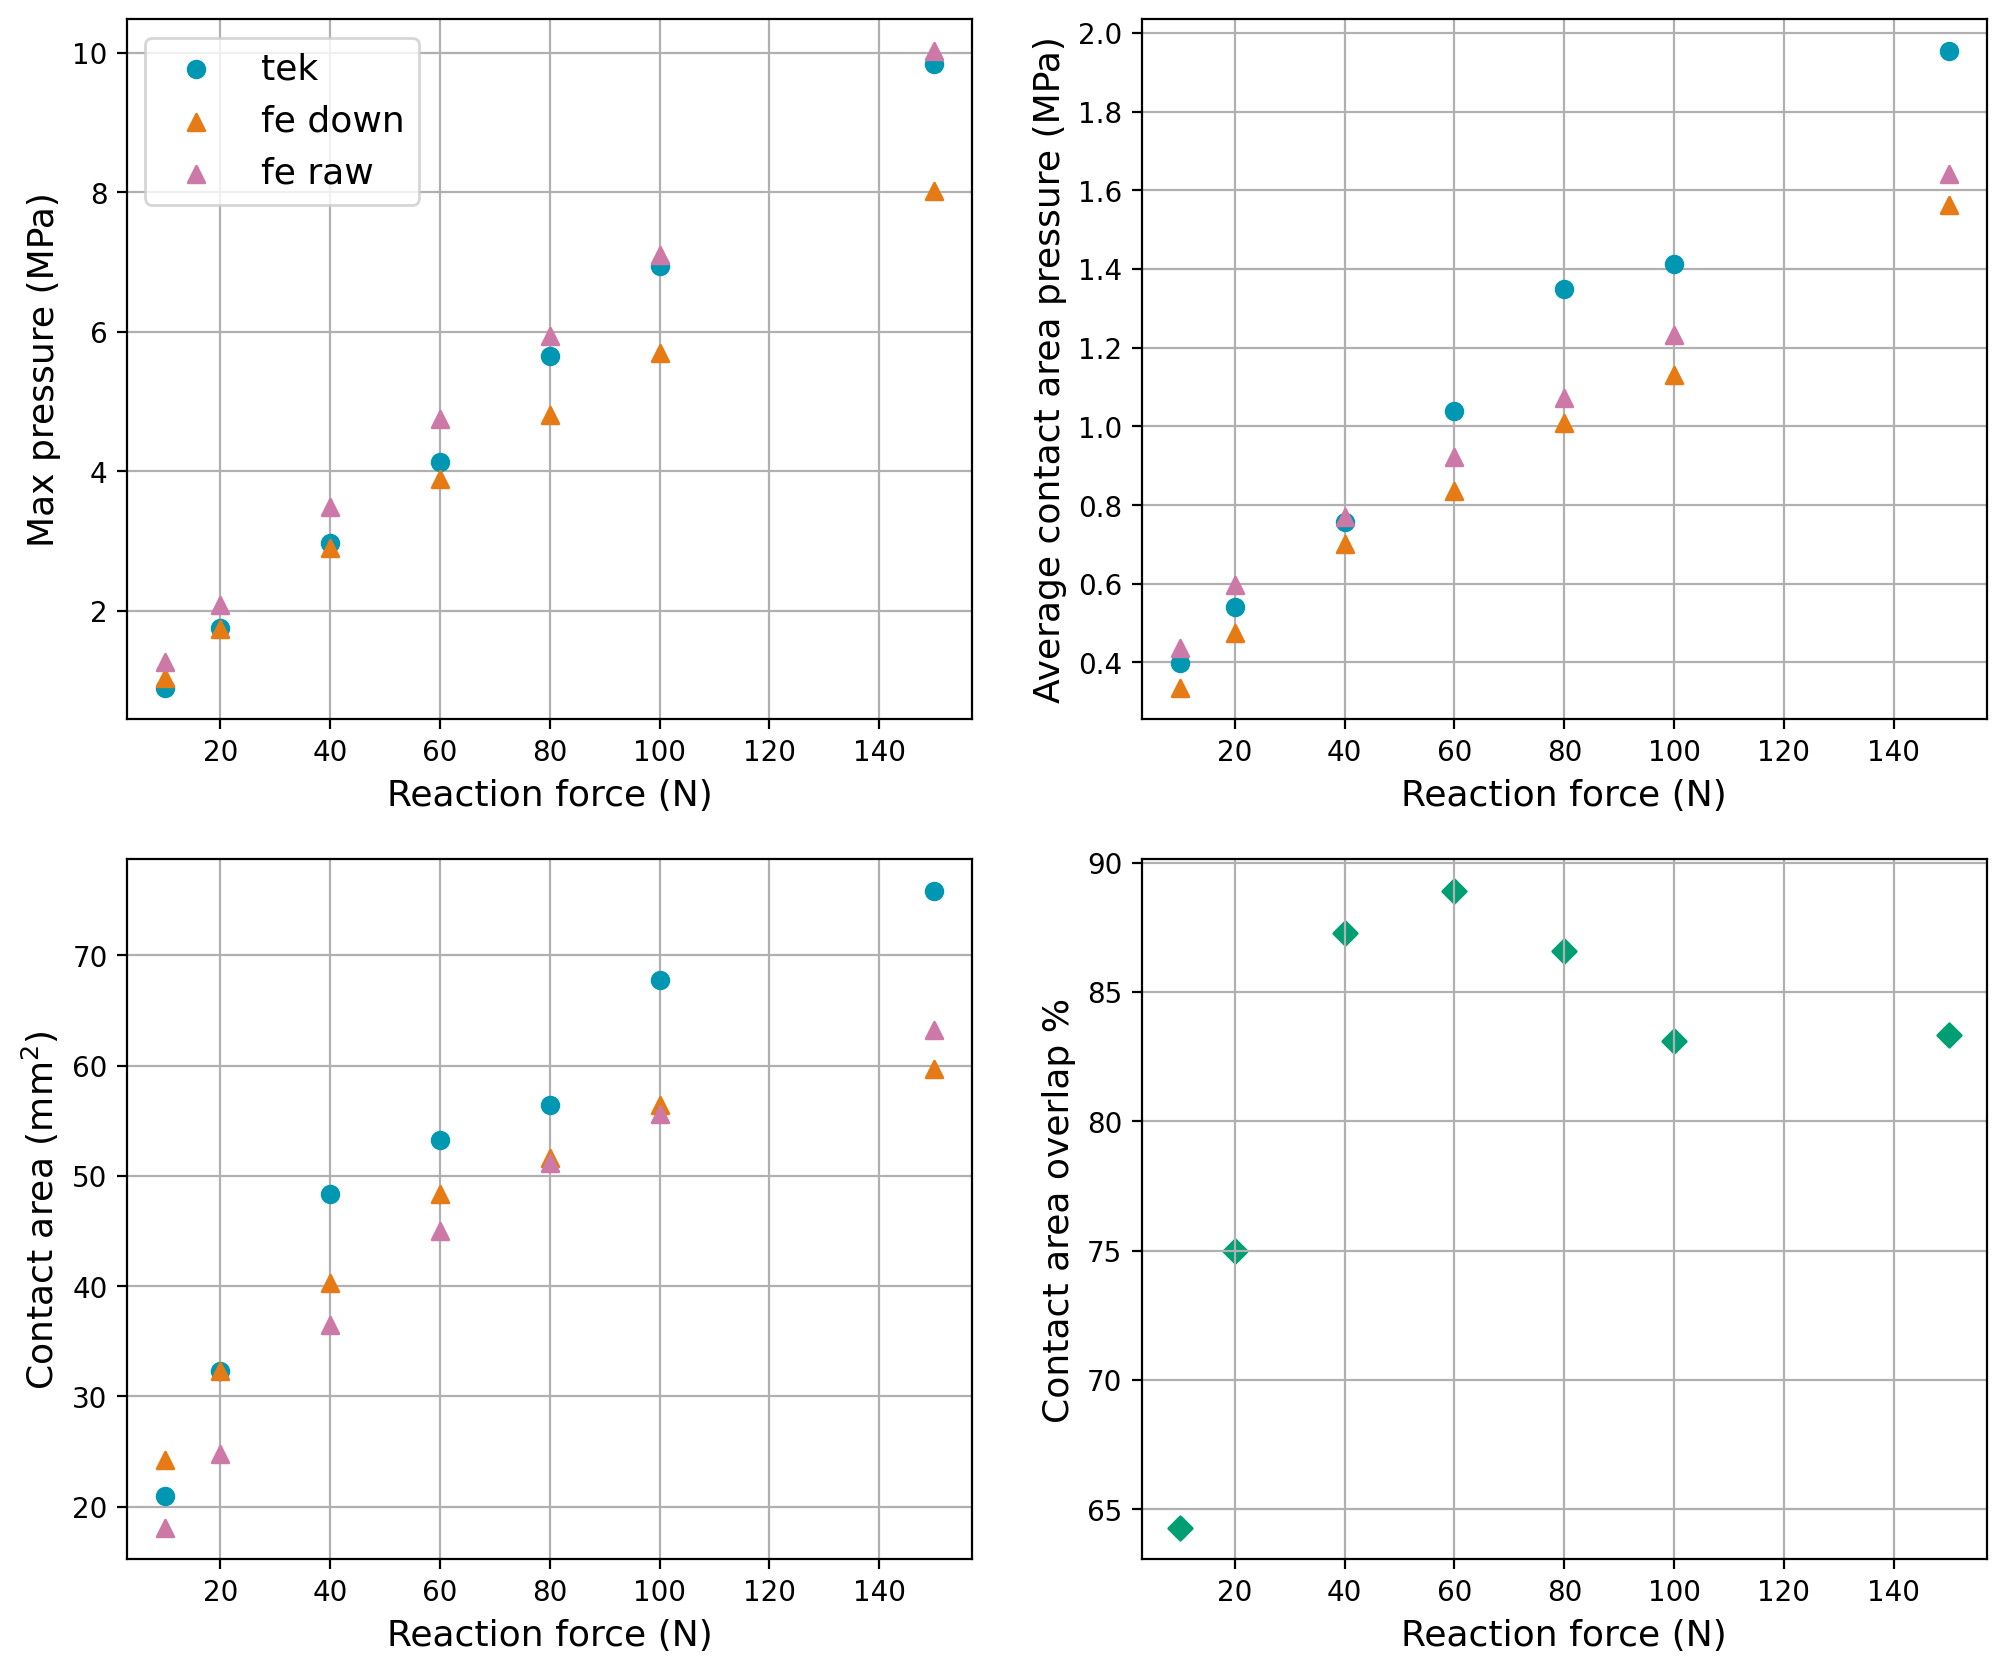

In [46]:
plot_comparison(
    def_errors.test_mets, def_errors.fe_grid_mets, def_errors.fe_mets, common_Fs, def_errors.fe_grid_data, def_errors.test_frames_mpa
    )

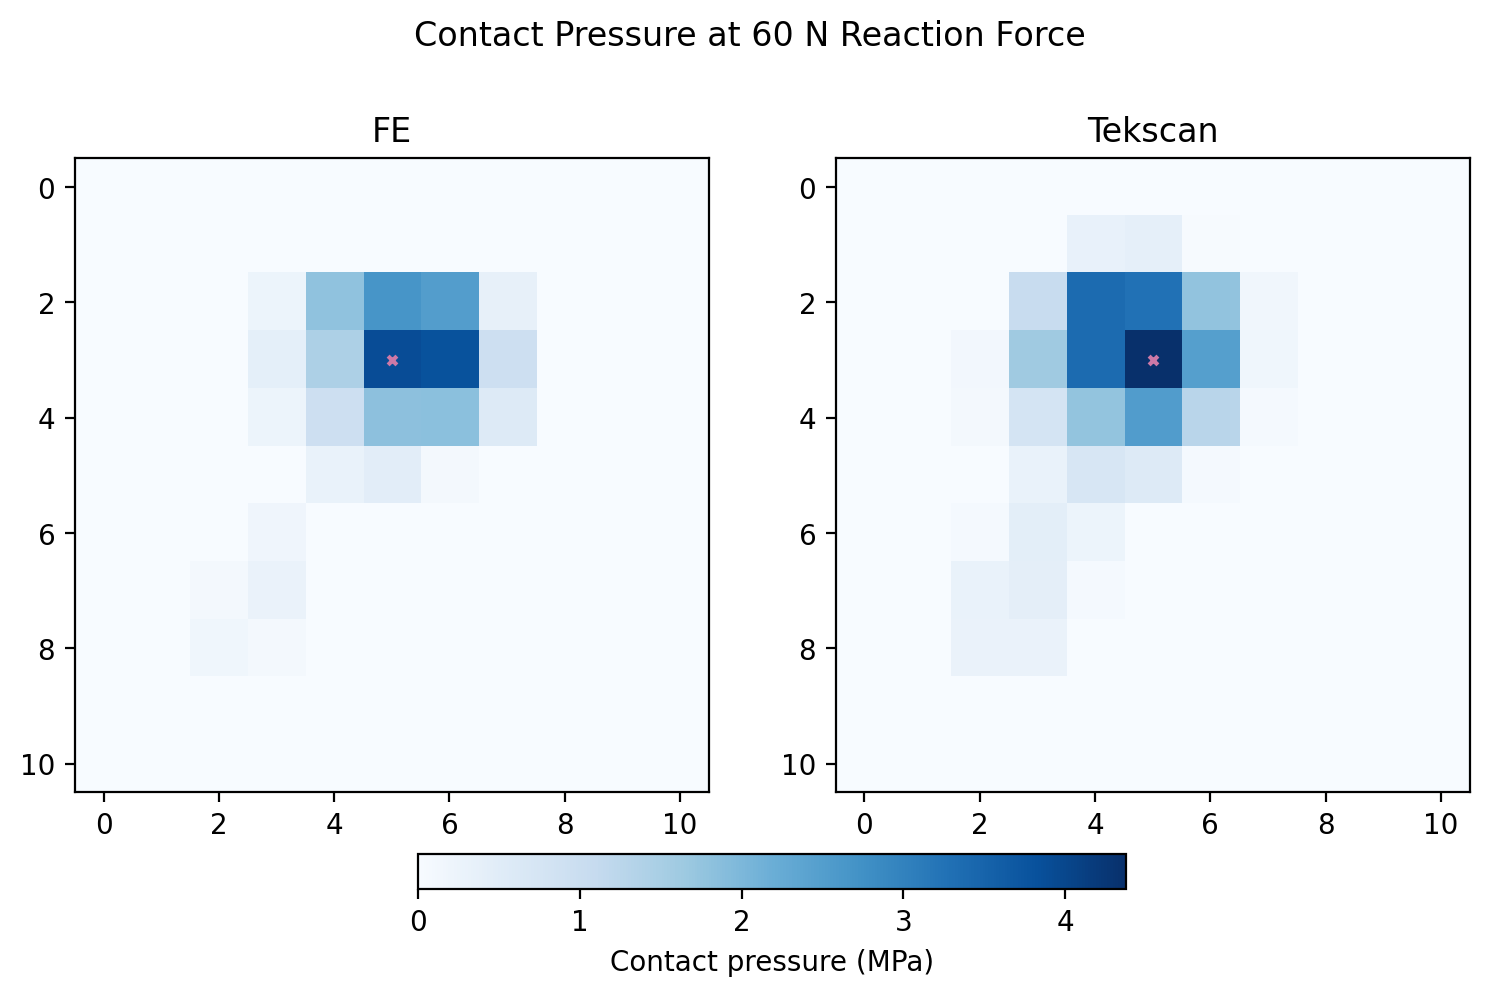

In [18]:
F = 60
plot_sensor_grids(F, def_errors.fe_grid_data, def_errors.test_frames_mpa)

In [31]:
def_errors.test_frames[100].max()

np.float64(158.93827160493828)